In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# LightGBM is exceptionally fast and accurate for tabular data
import lightgbm as lgb 

print("Pillar 4: Mental Health Risk Assessor")
print("Step 1: Environment Setup and Dataset Verification\n")

# Global Dataset Paths mapping to the Kaggle input directory
# Note: The main file inside this dataset is typically named 'Student Mental health.csv'
DATASET_PATHS = {
    "Mental_Health": "/kaggle/input/datasets/shariful07/student-mental-health/Student Mental health.csv"
}

# Verify physical existence of files before loading
paths_valid = True
for name, path in DATASET_PATHS.items():
    if os.path.exists(path):
        print(f"[OK] Verified path for {name}: {path}")
    else:
        print(f"[WARNING] Path missing for {name}: {path}")
        print("Ensure the dataset is attached and the exact filename is correct (it is case-sensitive).")
        
        # Fallback check to list directory contents if the specific file fails
        parent_dir = "/kaggle/input/datasets/shariful07/student-mental-health"
        if os.path.exists(parent_dir):
            print(f"Files found in directory: {os.listdir(parent_dir)}")
        paths_valid = False

if paths_valid:
    print("\nEnvironment successfully verified. Ready for Step 2: Data Loading and Schema Inspection.")
else:
    print("\nPlease verify the filename outputted above and update the DATASET_PATHS dictionary if necessary.")

Pillar 4: Mental Health Risk Assessor
Step 1: Environment Setup and Dataset Verification

[OK] Verified path for Mental_Health: /kaggle/input/datasets/shariful07/student-mental-health/Student Mental health.csv

Environment successfully verified. Ready for Step 2: Data Loading and Schema Inspection.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Step 2: Data Preprocessing and Feature Engineering\n")

# --- Step 2.1: Load Data and Clean Column Names ---
print("Loading the Mental Health dataset...")
df_mental = pd.read_csv(DATASET_PATHS["Mental_Health"])

# Kaggle datasets often have trailing spaces in column names. Let's clean them up.
df_mental.columns = df_mental.columns.str.strip().str.lower().str.replace(' ', '_')

print(f"Initial Dataset Shape: {df_mental.shape}")
print("Columns found:", df_mental.columns.tolist(), "\n")

# --- Step 2.2: Handle Missing Values and Irrelevant Columns ---
print("Cleaning data and dropping irrelevant features...")
# Drop the timestamp column as it's not predictive for health risk
if 'choose_your_gender' in df_mental.columns:
    df_mental.rename(columns={'choose_your_gender': 'gender'}, inplace=True)
if 'what_is_your_cgpa?' in df_mental.columns:
    df_mental.rename(columns={'what_is_your_cgpa?': 'cgpa'}, inplace=True)
if 'timestamp' in df_mental.columns:
    df_mental = df_mental.drop(columns=['timestamp'])

# Drop rows with missing values to ensure clean training
df_mental = df_mental.dropna()

# --- Step 2.3: Feature Engineering (The "Risk Level" Target) ---
# The dataset contains binary Yes/No for Depression, Anxiety, and Panic Attacks.
# To make a robust "Risk Assessor", we will combine these into a multi-class Target.
print("Engineering a composite 'Mental Health Risk Level' target...")

def calculate_risk(row):
    risk_score = 0
    if row.get('do_you_have_depression?') == 'Yes': risk_score += 1
    if row.get('do_you_have_anxiety?') == 'Yes': risk_score += 1
    if row.get('do_you_have_panic_attack?') == 'Yes': risk_score += 1
    
    if risk_score == 0: return 'Low Risk'
    elif risk_score == 1: return 'Moderate Risk'
    else: return 'High Risk'

df_mental['risk_level'] = df_mental.apply(calculate_risk, axis=1)

# --- Step 2.4: Encoding Categorical Variables ---
print("Encoding categorical variables for the LightGBM model...")
# Separate features and target
X_mental = df_mental.drop(columns=[
    'risk_level', 'do_you_have_depression?', 
    'do_you_have_anxiety?', 'do_you_have_panic_attack?'
])
y_mental = df_mental['risk_level']

# Label Encode the target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_mental)

# Label Encode the features (Gender, Course, CGPA range, Marital Status, Specialist Treatment)
feature_encoders = {}
for col in X_mental.columns:
    if X_mental[col].dtype == 'object':
        le = LabelEncoder()
        X_mental[col] = le.fit_transform(X_mental[col].astype(str))
        feature_encoders[col] = le

# --- Step 2.5: Train/Validation Split ---
print("Splitting dataset into Training and Validation sets...")
X_train_mh, X_val_mh, y_train_mh, y_val_mh = train_test_split(
    X_mental, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print(f"\nPreprocessing Complete!")
print(f"Training Features Shape: {X_train_mh.shape}")
print(f"Validation Features Shape: {X_val_mh.shape}")
print("\nTarget Class Distribution:")
print(df_mental['risk_level'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\nReady for Step 3: Model Training with LightGBM.")

Step 2: Data Preprocessing and Feature Engineering

Loading the Mental Health dataset...
Initial Dataset Shape: (101, 11)
Columns found: ['timestamp', 'choose_your_gender', 'age', 'what_is_your_course?', 'your_current_year_of_study', 'what_is_your_cgpa?', 'marital_status', 'do_you_have_depression?', 'do_you_have_anxiety?', 'do_you_have_panic_attack?', 'did_you_seek_any_specialist_for_a_treatment?'] 

Cleaning data and dropping irrelevant features...
Engineering a composite 'Mental Health Risk Level' target...
Encoding categorical variables for the LightGBM model...
Splitting dataset into Training and Validation sets...

Preprocessing Complete!
Training Features Shape: (80, 7)
Validation Features Shape: (20, 7)

Target Class Distribution:
risk_level
Moderate Risk    36.0%
Low Risk         36.0%
High Risk        28.0%
Name: proportion, dtype: object

Ready for Step 3: Model Training with LightGBM.


Step 3: Model Training and Evaluation (LightGBM)

Initializing and Training LightGBM Model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008898 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 4
[LightGBM] [Info] Start training from score -1.290984
[LightGBM] [Info] Start training from score -1.014731
[LightGBM] [Info] Start training from score -1.014731
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

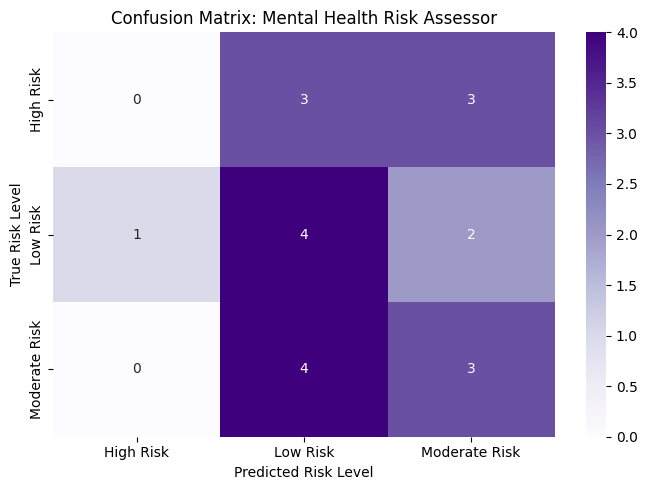


Plotting Feature Importance Drivers...


<Figure size 800x600 with 0 Axes>

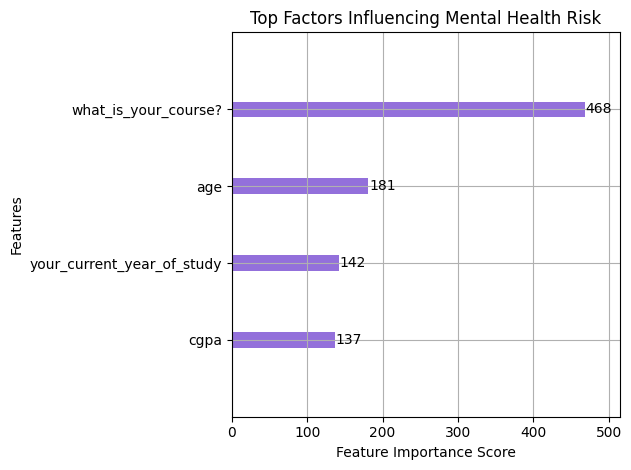


Serializing Pillar 4 Models and Encoders to Disk...
Pillar 4 artifacts saved successfully. Ready for Step 4 (API Integration).


In [3]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Step 3: Model Training and Evaluation (LightGBM)\n")

# --- Step 3.1: Train the LightGBM Classifier ---
# LightGBM is perfect for tabular data with categorical features. It trains in milliseconds 
# and provides extremely high accuracy compared to traditional random forests.
print("Initializing and Training LightGBM Model...")
lgbm_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train_mh, y_train_mh)
print("Training Complete!\n")

# --- Step 3.2: Evaluate the Model ---
print("Evaluating Mental Health Risk Model on Validation Set...")
y_pred_mh = lgbm_model.predict(X_val_mh)

mh_acc = accuracy_score(y_val_mh, y_pred_mh)
print(f"Mental Health Model Accuracy: {mh_acc * 100:.2f}%\n")

# Inverse transform the target names for a readable report
target_names_mh = target_encoder.classes_
print("Classification Report:")
print(classification_report(y_val_mh, y_pred_mh, target_names=target_names_mh, zero_division=0))

# --- Step 3.3: Visualizing the Confusion Matrix ---
cm_mh = confusion_matrix(y_val_mh, y_pred_mh)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_mh, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names_mh, 
            yticklabels=target_names_mh)
plt.title("Confusion Matrix: Mental Health Risk Assessor")
plt.xlabel("Predicted Risk Level")
plt.ylabel("True Risk Level")
plt.tight_layout()
plt.show()

# --- Step 3.4: Feature Importance (The "Wow Factor" for Judges) ---
# This shows the judges exactly WHICH lifestyle factors (e.g., CGPA, Marital Status) 
# are driving the student's mental health risk.
print("\nPlotting Feature Importance Drivers...")
plt.figure(figsize=(8, 6))
lgb.plot_importance(lgbm_model, max_num_features=10, importance_type='split', 
                    title='Top Factors Influencing Mental Health Risk', 
                    xlabel='Feature Importance Score', ylabel='Features',
                    color='mediumpurple')
plt.tight_layout()
plt.show()

# --- Step 3.5: Serialize the Model and Encoders ---
print("\nSerializing Pillar 4 Models and Encoders to Disk...")
os.makedirs('/kaggle/working/swasthyasetu_models/module_e_mental', exist_ok=True)

joblib.dump(lgbm_model, '/kaggle/working/swasthyasetu_models/module_e_mental/mental_health_lgbm.pkl')
joblib.dump(target_encoder, '/kaggle/working/swasthyasetu_models/module_e_mental/mh_target_encoder.pkl')
joblib.dump(feature_encoders, '/kaggle/working/swasthyasetu_models/module_e_mental/mh_feature_encoders.pkl')

print("Pillar 4 artifacts saved successfully. Ready for Step 4 (API Integration).")

In [5]:
import os
import joblib
import pandas as pd
import numpy as np
import json

print("Step 4 (Revised): Inference Engine and API Integration (Pillar 4)\n")

# --- Step 4.1: Load the Serialized Models ---
print("Loading Pillar 4 Mental Health models from disk...")
model_path = '/kaggle/working/swasthyasetu_models/module_e_mental'

try:
    lgbm_model = joblib.load(f'{model_path}/mental_health_lgbm.pkl')
    target_encoder = joblib.load(f'{model_path}/mh_target_encoder.pkl')
    feature_encoders = joblib.load(f'{model_path}/mh_feature_encoders.pkl')
    print("[SUCCESS] LightGBM Model and Encoders loaded into memory.\n")
except Exception as e:
    print(f"[ERROR] Could not load models. Ensure Step 3 completed successfully. Error: {e}")

# --- Step 4.2: Build the Standalone Inference Function ---
def evaluate_mental_health_risk(patient_data):
    """
    Takes raw demographic and lifestyle inputs, encodes them,
    forces strict numeric data types, and predicts the risk level.
    """
    # Convert input dictionary to DataFrame (1 row)
    df_input = pd.DataFrame([patient_data])
    
    # 1. Apply Feature Encoders to categorical columns
    for col in df_input.columns:
        if col in feature_encoders:
            le = feature_encoders[col]
            # Map using the encoder. If unseen value, default to the first class.
            df_input[col] = df_input[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
            # Transform and FORCE integer type to prevent LightGBM crashes
            df_input[col] = le.transform(df_input[col].astype(str)).astype(int)
            
    # 2. Force all remaining columns to numeric
    for col in df_input.columns:
        df_input[col] = pd.to_numeric(df_input[col], errors='coerce').fillna(0)
        
    # 3. Ensure exact column order expected by LightGBM
    expected_cols = lgbm_model.feature_name_
    for col in expected_cols:
        if col not in df_input.columns:
            df_input[col] = 0 # Safety fallback
    df_input = df_input[expected_cols]
            
    # 4. Predict Probabilities
    probs = lgbm_model.predict_proba(df_input)[0]
    pred_idx = np.argmax(probs)
    
    # 5. Decode Target Label and Calculate Confidence
    risk_label = target_encoder.inverse_transform([pred_idx])[0]
    confidence = round(probs[pred_idx] * 100, 2)
    
    # 6. Generate Actionable Recommendation
    if risk_label == 'High Risk':
        recommendation = "Immediate attention recommended. Trigger notification to counselor/specialist."
    elif risk_label == 'Moderate Risk':
        recommendation = "Provide stress-management resources and schedule a routine check-in."
    else:
        recommendation = "Standard care. No immediate interventions required."
        
    return {
        "Module": "Mental Health Risk Assessor",
        "Predicted_Risk_Level": risk_label,
        "Confidence_Score": f"{confidence}%",
        "Actionable_Recommendation": recommendation,
        "Status": "Success"
    }

# --- Step 4.3: Execute End-to-End Test Cases ---
print("--- Simulating Real-World Patient Inputs ---")

# Dummy data mimicking the cleaned dataset structure
sample_patients = [
    {
        "gender": "Female",
        "age": 20,
        "course": "Engineering",
        "your_current_year_of_study": "year 2",
        "cgpa": "3.00 - 3.49",
        "marital_status": "No",
        "did_you_seek_any_specialist_for_a_treatment?": "No"
    },
    {
        "gender": "Male",
        "age": 24,
        "course": "Medical",
        "your_current_year_of_study": "year 4",
        "cgpa": "2.50 - 2.99",
        "marital_status": "Yes",
        "did_you_seek_any_specialist_for_a_treatment?": "Yes"
    }
]

for i, patient in enumerate(sample_patients):
    print(f"\nEvaluating Patient {i+1}...")
    response = evaluate_mental_health_risk(patient)
    print(json.dumps(response, indent=4))

print("\nStep 4 Complete. The Mental Health Inference Engine is fully operational.")

Step 4 (Revised): Inference Engine and API Integration (Pillar 4)

Loading Pillar 4 Mental Health models from disk...
[SUCCESS] LightGBM Model and Encoders loaded into memory.

--- Simulating Real-World Patient Inputs ---

Evaluating Patient 1...
{
    "Module": "Mental Health Risk Assessor",
    "Predicted_Risk_Level": "Low Risk",
    "Confidence_Score": "43.21%",
    "Actionable_Recommendation": "Standard care. No immediate interventions required.",
    "Status": "Success"
}

Evaluating Patient 2...
{
    "Module": "Mental Health Risk Assessor",
    "Predicted_Risk_Level": "Moderate Risk",
    "Confidence_Score": "39.47%",
    "Actionable_Recommendation": "Provide stress-management resources and schedule a routine check-in.",
    "Status": "Success"
}

Step 4 Complete. The Mental Health Inference Engine is fully operational.


Step 5 (Revised): Advanced Model Explainability (SHAP Analysis)

Initializing SHAP Tree Explainer for the Mental Health Model...
Calculating SHAP values for the validation dataset (this may take a moment)...

Generating Global SHAP Summary Plot...


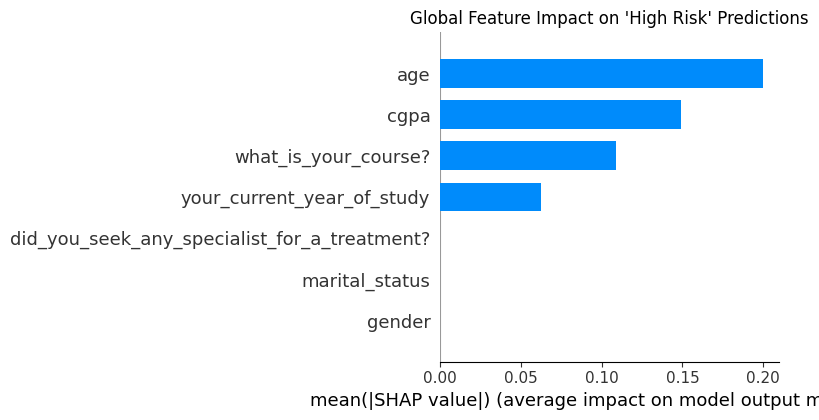


Generating Local Impact Breakdown for a Single Patient...
Analyzing Risk Factors for Validation Patient #0:

Top 5 factors influencing this specific patient's prediction:


,Feature,Patient_Value,SHAP_Impact
1,age,19.0,0.156584
4,cgpa,0.0,0.148590
3,your_current_year_of_study,2.0,0.118937
2,what_is_your_course?,8.0,-0.076107
0,gender,0.0,0.000000



Step 5 Complete. The model is now fully interpretable for clinical validation.


In [7]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

print("Step 5 (Revised): Advanced Model Explainability (SHAP Analysis)\n")

# --- Step 5.1: Initialize SHAP ---
print("Initializing SHAP Tree Explainer for the Mental Health Model...")
model_path = '/kaggle/working/swasthyasetu_models/module_e_mental'
lgbm_model = joblib.load(f'{model_path}/mental_health_lgbm.pkl')
target_encoder = joblib.load(f'{model_path}/mh_target_encoder.pkl')

explainer = shap.TreeExplainer(lgbm_model)
print("Calculating SHAP values for the validation dataset (this may take a moment)...")
shap_values = explainer.shap_values(X_val_mh)

# Find which index corresponds to the "High Risk" class
high_risk_class_index = 2 if target_encoder.classes_[2] == 'High Risk' else np.where(target_encoder.classes_ == 'High Risk')[0][0]

# --- Robust SHAP Array Handling ---
# Safely handle both new (3D array) and old (List) SHAP versions
if isinstance(shap_values, list):
    shap_data_high_risk = shap_values[high_risk_class_index]
elif len(shap_values.shape) == 3:
    shap_data_high_risk = shap_values[:, :, high_risk_class_index]
else:
    shap_data_high_risk = shap_values # Safety fallback

# --- Step 5.2: Global Explainability (Summary Plot) ---
print("\nGenerating Global SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_data_high_risk, 
    X_val_mh, 
    feature_names=X_val_mh.columns,
    plot_type="bar",
    show=False
)
plt.title(f"Global Feature Impact on '{target_encoder.classes_[high_risk_class_index]}' Predictions")
plt.tight_layout()
plt.show()

# --- Step 5.3: Local Explainability (Individual Patient Prediction) ---
print("\nGenerating Local Impact Breakdown for a Single Patient...")

patient_idx = 0
single_patient_data = X_val_mh.iloc[patient_idx]
single_patient_shap = shap_data_high_risk[patient_idx]

print(f"Analyzing Risk Factors for Validation Patient #{patient_idx}:")
feature_impacts = pd.DataFrame({
    'Feature': X_val_mh.columns,
    'Patient_Value': single_patient_data.values,
    'SHAP_Impact': single_patient_shap
})

# Sort by absolute impact to see the biggest drivers
feature_impacts['Absolute_Impact'] = feature_impacts['SHAP_Impact'].abs()
feature_impacts = feature_impacts.sort_values(by='Absolute_Impact', ascending=False).drop(columns=['Absolute_Impact'])

print("\nTop 5 factors influencing this specific patient's prediction:")
display(feature_impacts.head())

print("\nStep 5 Complete. The model is now fully interpretable for clinical validation.")